<a href="https://colab.research.google.com/github/Mounanjali19/AITrafficPredictionandRouteOptimization/blob/main/plan_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install osmnx torch-geometric shap stable-baselines3


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 23.0 MB/s eta 0:00:00


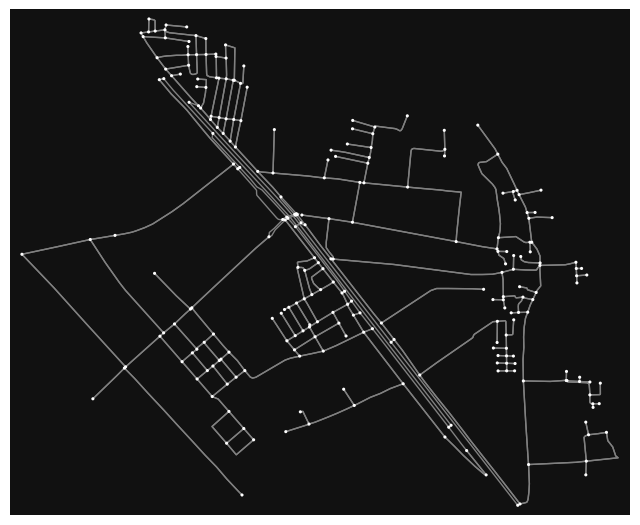

In [ ]:
import osmnx as ox

location = "Bommasandra, Bengaluru, India"  # includes Electronic City + Phase 1 area
G = ox.graph_from_place(location, network_type='drive')
ox.plot_graph(G, node_size=5, edge_color="gray")
ox.save_graphml(G, "ecity_raw.graphml")



In [ ]:
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())


Nodes: 250
Edges: 598


In [ ]:
import os
import json
import random
import numpy as np
import pandas as pd
import osmnx as ox
import networkx as nx

# -------- GLOBAL SEED FOR FULL REPRODUCIBILITY --------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [ ]:
# Load previously saved canonical graph
G = ox.load_graphml("/content/ecity_raw.graphml")

In [ ]:
# Convert to GeoDataFrame with edges
edges = ox.graph_to_gdfs(G, nodes=False).reset_index()

# Normalize highway column
def hw_to_str(x):
    if isinstance(x, list):
        return ",".join([str(i) for i in x])
    if pd.isna(x):
        return ""
    return str(x)

edges["highway"] = edges["highway"].apply(hw_to_str)

# Deterministic ordering
sort_cols = ["u", "v", "key", "length"]
sort_cols = [c for c in sort_cols if c in edges.columns]
edges = edges.sort_values(sort_cols).reset_index(drop=True)

# Assign stable edge_id
edges["edge_id"] = edges.index.astype(int)

# Keep needed columns
edges = edges[["edge_id", "u", "v", "key", "length", "highway", "geometry"]]

# Save canonical edges
edges_path = "/content/ecity_edges_canonical.csv"
edges.to_csv(edges_path, index=False)

print("Saved:", edges_path, edges.shape)

# ---------------- Save node map ----------------
nodes = list(G.nodes())
node_map = {int(n): i for i, n in enumerate(nodes)}

with open("/content/node_map.json", "w") as f:
    json.dump(node_map, f)

print("Saved node_map.json")

# ---------------- Save edge_index ----------------
source = edges["u"].map(node_map).values
target = edges["v"].map(node_map).values
edge_index = np.vstack([source, target]).astype(np.int64)

np.save("/content/edge_index.npy", edge_index)
print("Saved edge_index.npy, shape:", edge_index.shape)

Saved: /content/ecity_edges_canonical.csv (612, 7)
Saved node_map.json
Saved edge_index.npy, shape: (2, 612)


In [ ]:
import pandas as pd
# ---------- LOAD CANONICAL EDGES ----------
edges = pd.read_csv("/content/ecity_edges_canonical.csv")

# ---------- TIME PARAMETERS ----------
DAYS = 60
FREQ = "5min"
START = "2025-01-01"

rng = pd.date_range(START, periods=DAYS * 24 * 12, freq=FREQ)
N = len(rng)

# --------- BASE SPEED MAPPING ----------
def base_speed(hwy):
    if hwy.startswith(("motorway","trunk","primary")): return 55
    if hwy.startswith(("secondary","tertiary")): return 42
    if hwy.startswith(("residential","unclassified")): return 30
    return 35

edges["base_speed"] = edges["highway"].apply(base_speed)

# ---------- DEGREE CENTRALITY ----------
deg = edges[["u","v"]].melt(value_name="node").value_counts("node").reset_index()
deg = deg.rename(columns={"node":"node_id","count":"deg"})

edges = edges.merge(deg.rename(columns={"node_id":"u","deg":"deg_u"}), on="u", how="left")
edges = edges.merge(deg.rename(columns={"node_id":"v","deg":"deg_v"}), on="v", how="left")

edges[["deg_u","deg_v"]] = edges[["deg_u","deg_v"]].fillna(1)
edges["junction_factor"] = (edges["deg_u"] + edges["deg_v"]) / 2
edges["junction_factor"] /= edges["junction_factor"].max()

# ---------- DETERMINISTIC EVENT EDGES ----------
event_edges = set(edges.sample(frac=0.25, random_state=SEED)["edge_id"])

# ---------- WEATHER / EVENT SERIES ----------
is_rain = pd.Series(False, index=rng)
rain_days = np.random.choice(pd.date_range(START, periods=DAYS, freq="D"), size=10, replace=False)
for d in rain_days:
    is_rain.loc[d:d+pd.Timedelta(days=1)] = True

is_event = pd.Series(False, index=rng)
event_days = np.random.choice(pd.date_range(START, periods=DAYS, freq="D"), size=6, replace=False)
for d in event_days:
    is_event.loc[d+pd.Timedelta(hours=17): d+pd.Timedelta(hours=22)] = True

# ---------- DIURNAL PROFILE ----------
minute_of_day = rng.hour*60 + rng.minute
morning = np.exp(-((minute_of_day-540)/140)**2)
evening = np.exp(-((minute_of_day-1110)/160)**2)
diurnal = morning + evening

dow = rng.weekday
is_weekend = np.isin(dow, [5,6])

rain_mult  = np.where(is_rain, 0.78, 1.0)
event_mult = np.where(is_event, 0.72, 1.0)
weekend_mult = np.where(is_weekend, 0.6, 1.0)

# ---------- GLOBAL NOISE (DETERMINISTIC) ----------
city_noise = np.random.normal(0, 0.04, size=N)
city_noise = pd.Series(city_noise).rolling(6, center=True, min_periods=1).mean().values

# ---------- GENERATE PER-EDGE SERIES ----------
rows = []
for _, e in edges.iterrows():
    edge_id = e.edge_id
    L = e.length
    base = e.base_speed
    jf = e.junction_factor

    sens = 0.75 + 0.5*np.random.rand()

    edge_noise = np.random.normal(0,0.05,size=N)
    edge_noise = pd.Series(edge_noise).rolling(6,center=True,min_periods=1).mean().values

    local_event = event_mult if edge_id in event_edges else 1.0

    speed = base * (
        1
        - 0.35*sens*(diurnal/diurnal.max())
        - 0.15*jf
    )
    speed *= weekend_mult
    speed *= rain_mult
    speed *= local_event
    speed *= (1 + city_noise + edge_noise)
    speed = np.clip(speed, 8, base + 15)

    travel_time = L / (speed * (1000/3600))

    veh_count = (1.8*diurnal/diurnal.max() + 0.6)
    veh_count = veh_count * (1 + 0.3*np.random.randn(N)) * 50
    veh_count = np.maximum(0, veh_count).astype(int)

    df = pd.DataFrame({
        "edge_id": edge_id,
        "timestamp": rng,
        "avg_speed_kmph": speed,
        "travel_time_sec": travel_time,
        "vehicle_count": veh_count,
        "is_rain": is_rain.astype(int).values,
        "is_event": is_event.astype(int).values,
        "is_weekend": is_weekend.astype(int),
        "minute_of_day": minute_of_day,
        "day_of_week": dow,
        "junction_factor": jf
    })

    rows.append(df)

ts = pd.concat(rows, ignore_index=True)
ts.to_csv("/content/ecity_timeseries_5min_60d.csv", index=False)

print("Saved time-series:", ts.shape)
ts.head()

Saved time-series: (10575360, 11)


,edge_id,timestamp,avg_speed_kmph,travel_time_sec,vehicle_count,is_rain,is_event,is_weekend,minute_of_day,day_of_week,junction_factor
0,0,2025-01-01 00:00:00,20.527905,23.612384,25,1,0,0,0,2,0.875
1,0,2025-01-01 00:05:00,20.035711,24.192442,31,1,0,0,5,2,0.875
2,0,2025-01-01 00:10:00,20.311537,23.863913,25,1,0,0,10,2,0.875
3,0,2025-01-01 00:15:00,19.988931,24.249059,47,1,0,0,15,2,0.875
4,0,2025-01-01 00:20:00,19.763435,24.525735,24,1,0,0,20,2,0.875


In [ ]:
G = ox.load_graphml("/content/ecity_raw.graphml")


In [ ]:
# ---- stable_edge_export.py (run once and reuse results) ----
import os, json
import osmnx as ox
import pandas as pd
import numpy as np
import networkx as nx

# load saved graph (do not re-download)
G = ox.load_graphml("/content/ecity_raw.graphml")

# ensure it's a MultiDiGraph
if not isinstance(G, nx.MultiDiGraph):
    G = nx.MultiDiGraph(G)

# convert to GeoDataFrame with edges including 'key' if present
# graph_to_gdfs for MultiDiGraph returns index (u, v, key) in the index
edges = ox.graph_to_gdfs(G, nodes=False).reset_index()

# If the index columns are named ('u','v','key') or a MultiIndex, ensure they exist
if ('u' not in edges.columns) or ('v' not in edges.columns):
    # If ox returned a MultiIndex, the reset_index may create columns named level_0...
    # Try to detect and rename
    idx_names = list(edges.columns[:3])
    # attempt to infer u,v,key positions
    # safe fallback: reconstruct from graph edges
    rows = []
    for u, v, key, data in G.edges(keys=True, data=True):
        row = {'u': u, 'v': v, 'key': key}
        row.update(data)
        rows.append(row)
    edges = pd.DataFrame(rows)

# Normalize highway column to string (avoid list/NaN issues)
def hw_to_str(x):
    if isinstance(x, list):
        return ",".join([str(i) for i in x])
    if pd.isna(x):
        return ""
    return str(x)

if 'highway' in edges.columns:
    edges['highway'] = edges['highway'].apply(hw_to_str)
else:
    edges['highway'] = ""

# create deterministic ordering: sort by u, v, key (if key exists), and length
sort_cols = ['u','v']
if 'key' in edges.columns:
    sort_cols.append('key')
if 'length' in edges.columns:
    sort_cols.append('length')

edges = edges.sort_values(by=sort_cols).reset_index(drop=True)

# create stable edge_id
edges['edge_id'] = edges.index.astype(int)

# keep only the useful columns (ensure geometry kept)
cols_keep = ['edge_id','u','v']
if 'key' in edges.columns:
    cols_keep.append('key')
if 'length' in edges.columns:
    cols_keep.append('length')
cols_keep += ['highway','geometry']

edges = edges[[c for c in cols_keep if c in edges.columns]]

# save canonical CSV (overwrite intentionally, single source of truth)
csv_path = "/content/ecity_edges_canonical.csv"
edges.to_csv(csv_path, index=False)
print("Saved canonical edges to:", csv_path)
print("Edges shape:", edges.shape)

# --- Save node mapping (node id -> index) for PyG stable node indexing ---
nodes = list(G.nodes())
node_map = {int(n): i for i,n in enumerate(nodes)}  # maps original node id -> contiguous idx
with open("/content/node_map.json","w") as f:
    json.dump(node_map, f)
print("Saved node_map.json with {} nodes".format(len(node_map)))

# --- Create and save edge_index (source,target) as numpy arrays using node_map ---
source = edges['u'].map(node_map).values
target = edges['v'].map(node_map).values
edge_index = np.vstack([source, target]).astype(np.int64)
np.save("/content/edge_index.npy", edge_index)
print("Saved edge_index.npy shape:", edge_index.shape)


Saved canonical edges to: /content/ecity_edges_canonical.csv
Edges shape: (598, 7)
Saved node_map.json with 250 nodes
Saved edge_index.npy shape: (2, 598)


In [ ]:
# Convert to GeoDataFrame with edges
edges = ox.graph_to_gdfs(G, nodes=False).reset_index()

# Normalize highway column
def hw_to_str(x):
    if isinstance(x, list):
        return ",".join([str(i) for i in x])
    if pd.isna(x):
        return ""
    return str(x)

edges["highway"] = edges["highway"].apply(hw_to_str)

# Deterministic ordering
sort_cols = ["u", "v", "key", "length"]
sort_cols = [c for c in sort_cols if c in edges.columns]
edges = edges.sort_values(sort_cols).reset_index(drop=True)

# Assign stable edge_id
edges["edge_id"] = edges.index.astype(int)

# Keep needed columns
edges = edges[["edge_id", "u", "v", "key", "length", "highway", "geometry"]]

# Save canonical edges
edges_path = "/content/ecity_edges_canonical.csv"
edges.to_csv(edges_path, index=False)

print("Saved:", edges_path, edges.shape)

# ---------------- Save node map ----------------
nodes = list(G.nodes())
node_map = {int(n): i for i, n in enumerate(nodes)}

with open("/content/node_map.json", "w") as f:
    json.dump(node_map, f)

print("Saved node_map.json")

# ---------------- Save edge_index ----------------
source = edges["u"].map(node_map).values
target = edges["v"].map(node_map).values
edge_index = np.vstack([source, target]).astype(np.int64)

np.save("/content/edge_index.npy", edge_index)
print("Saved edge_index.npy, shape:", edge_index.shape)


Saved: /content/ecity_edges_canonical.csv (590, 7)
Saved node_map.json
Saved edge_index.npy, shape: (2, 590)


In [ ]:
import pandas as pd
# ---------- LOAD CANONICAL EDGES ----------
edges = pd.read_csv("/content/ecity_edges_canonical.csv")

# ---------- TIME PARAMETERS ----------
DAYS = 60
FREQ = "5min"
START = "2025-01-01"

rng = pd.date_range(START, periods=DAYS * 24 * 12, freq=FREQ)
N = len(rng)

# --------- BASE SPEED MAPPING ----------
def base_speed(hwy):
    if hwy.startswith(("motorway","trunk","primary")): return 55
    if hwy.startswith(("secondary","tertiary")): return 42
    if hwy.startswith(("residential","unclassified")): return 30
    return 35

edges["base_speed"] = edges["highway"].apply(base_speed)

# ---------- DEGREE CENTRALITY ----------
deg = edges[["u","v"]].melt(value_name="node").value_counts("node").reset_index()
deg = deg.rename(columns={"node":"node_id","count":"deg"})

edges = edges.merge(deg.rename(columns={"node_id":"u","deg":"deg_u"}), on="u", how="left")
edges = edges.merge(deg.rename(columns={"node_id":"v","deg":"deg_v"}), on="v", how="left")

edges[["deg_u","deg_v"]] = edges[["deg_u","deg_v"]].fillna(1)
edges["junction_factor"] = (edges["deg_u"] + edges["deg_v"]) / 2
edges["junction_factor"] /= edges["junction_factor"].max()

# ---------- DETERMINISTIC EVENT EDGES ----------
event_edges = set(edges.sample(frac=0.25, random_state=SEED)["edge_id"])

# ---------- WEATHER / EVENT SERIES ----------
is_rain = pd.Series(False, index=rng)
rain_days = np.random.choice(pd.date_range(START, periods=DAYS, freq="D"), size=10, replace=False)
for d in rain_days:
    is_rain.loc[d:d+pd.Timedelta(days=1)] = True

is_event = pd.Series(False, index=rng)
event_days = np.random.choice(pd.date_range(START, periods=DAYS, freq="D"), size=6, replace=False)
for d in event_days:
    is_event.loc[d+pd.Timedelta(hours=17): d+pd.Timedelta(hours=22)] = True

# ---------- DIURNAL PROFILE ----------
minute_of_day = rng.hour*60 + rng.minute
morning = np.exp(-((minute_of_day-540)/140)**2)
evening = np.exp(-((minute_of_day-1110)/160)**2)
diurnal = morning + evening

dow = rng.weekday
is_weekend = np.isin(dow, [5,6])

rain_mult  = np.where(is_rain, 0.78, 1.0)
event_mult = np.where(is_event, 0.72, 1.0)
weekend_mult = np.where(is_weekend, 0.6, 1.0)

# ---------- GLOBAL NOISE (DETERMINISTIC) ----------
city_noise = np.random.normal(0, 0.04, size=N)
city_noise = pd.Series(city_noise).rolling(6, center=True, min_periods=1).mean().values

# ---------- GENERATE PER-EDGE SERIES ----------
rows = []
for _, e in edges.iterrows():
    edge_id = e.edge_id
    L = e.length
    base = e.base_speed
    jf = e.junction_factor

    sens = 0.75 + 0.5*np.random.rand()

    edge_noise = np.random.normal(0,0.05,size=N)
    edge_noise = pd.Series(edge_noise).rolling(6,center=True,min_periods=1).mean().values

    local_event = event_mult if edge_id in event_edges else 1.0

    speed = base * (
        1
        - 0.35*sens*(diurnal/diurnal.max())
        - 0.15*jf
    )
    speed *= weekend_mult
    speed *= rain_mult
    speed *= local_event
    speed *= (1 + city_noise + edge_noise)
    speed = np.clip(speed, 8, base + 15)

    travel_time = L / (speed * (1000/3600))

    veh_count = (1.8*diurnal/diurnal.max() + 0.6)
    veh_count = veh_count * (1 + 0.3*np.random.randn(N)) * 50
    veh_count = np.maximum(0, veh_count).astype(int)

    df = pd.DataFrame({
        "edge_id": edge_id,
        "timestamp": rng,
        "avg_speed_kmph": speed,
        "travel_time_sec": travel_time,
        "vehicle_count": veh_count,
        "is_rain": is_rain.astype(int).values,
        "is_event": is_event.astype(int).values,
        "is_weekend": is_weekend.astype(int),
        "minute_of_day": minute_of_day,
        "day_of_week": dow,
        "junction_factor": jf
    })

    rows.append(df)

ts = pd.concat(rows, ignore_index=True)
ts.to_csv("/content/ecity_timeseries_5min_60d.csv", index=False)

print("Saved time-series:", ts.shape)
ts.head()


FileNotFoundError: [Errno 2] No such file or directory: '/content/ecity_edges_canonical.csv'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import shutil

shutil.copy(
    "/content/ecity_edges_canonical.csv",
    "/content/drive/MyDrive/ecity_edges_canonical.csv"
)

print("Copied to Google Drive!")

Copied to Google Drive!


In [ ]:
import zipfile

with zipfile.ZipFile("/content/ecity_timeseries.zip", 'w', zipfile.ZIP_DEFLATED) as z:
    z.write("/content/drive/MyDrive/Traffic_Project/ecity_timeseries_5min_60d.csv", arcname="ecity_timeseries_5min_60d.csv")

from google.colab import files
files.download("/content/ecity_timeseries.zip")

In [ ]:
from google.colab import files

files.download(
    "/content/drive/MyDrive/ecity_edges_canonical.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
ts = pd.read_csv("/content/ecity_timeseries_5min_60d.csv")
ts.head(), ts.shape


(   edge_id            timestamp  avg_speed_kmph  travel_time_sec  \
 0        0  2025-01-01 00:00:00       20.527905        23.612384   
 1        0  2025-01-01 00:05:00       20.035711        24.192442   
 2        0  2025-01-01 00:10:00       20.311537        23.863913   
 3        0  2025-01-01 00:15:00       19.988931        24.249059   
 4        0  2025-01-01 00:20:00       19.763435        24.525735   
 
    vehicle_count  is_rain  is_event  is_weekend  minute_of_day  day_of_week  \
 0             25        1         0           0              0            2   
 1             31        1         0           0              5            2   
 2             25        1         0           0             10            2   
 3             47        1         0           0             15            2   
 4             24        1         0           0             20            2   
 
    junction_factor  
 0            0.875  
 1            0.875  
 2            0.875  
 3            

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!find /content -name "ecity_timeseries_5min_60d.csv"



/content/ecity_timeseries_5min_60d.csv


In [ ]:
# Create 30-min ahead label per edge
ts['target_speed_kmph'] = ts.groupby('edge_id')['avg_speed_kmph'].shift(-6)


In [ ]:
import pandas as pd

# Load dataset
ts = pd.read_csv("/content/ecity_timeseries_5min_60d.csv")


# Create 30-min-ahead target (6 steps because 5min*6 = 30 min)
ts['target_speed_kmph'] = ts.groupby('edge_id')['avg_speed_kmph'].shift(-6)

# Drop last 6 rows per edge (where label is NaN)
ts = ts.dropna(subset=['target_speed_kmph'])

ts.head(), ts.shape


(   edge_id            timestamp  avg_speed_kmph  travel_time_sec  \
 0        0  2025-01-01 00:00:00       20.527905        23.612384   
 1        0  2025-01-01 00:05:00       20.035711        24.192442   
 2        0  2025-01-01 00:10:00       20.311537        23.863913   
 3        0  2025-01-01 00:15:00       19.988931        24.249059   
 4        0  2025-01-01 00:20:00       19.763435        24.525735   
 
    vehicle_count  is_rain  is_event  is_weekend  minute_of_day  day_of_week  \
 0             25        1         0           0              0            2   
 1             31        1         0           0              5            2   
 2             25        1         0           0             10            2   
 3             47        1         0           0             15            2   
 4             24        1         0           0             20            2   
 
    junction_factor  target_speed_kmph  
 0            0.875          19.657869  
 1            0.875 

In [ ]:
ts['timestamp'] = pd.to_datetime(ts['timestamp'])
ts = ts.sort_values(['edge_id', 'timestamp']).reset_index(drop=True)



In [ ]:
features = [
    'avg_speed_kmph',
    'vehicle_count',
    'is_weekend',
    'is_rain',
    'is_event',
    'minute_of_day',
    'day_of_week',
    'junction_factor'
]

target = 'target_speed_kmph'


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# ---------------- Train/Val/Test Split (time-based, NO shuffle) ----------------
# Example split — adjust ratios to match your original code
n = len(ts)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

ts_train = ts.iloc[:train_end]
ts_val   = ts.iloc[train_end:val_end]
ts_test  = ts.iloc[val_end:]

# ---------------- Scaling ----------------
scaler = MinMaxScaler()

# Fit only on training data
scaler.fit(ts_train[features])

# Transform all splits
ts_train[features] = scaler.transform(ts_train[features])
ts_val[features]   = scaler.transform(ts_val[features])
ts_test[features]  = scaler.transform(ts_test[features])


/tmp/ipython-input-3790253932.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ts_train[features] = scaler.transform(ts_train[features])
/tmp/ipython-input-3790253932.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ts_val[features]   = scaler.transform(ts_val[features])
/tmp/ipython-input-3790253932.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# ---------------------------------------------
# 1. LOAD CORRECT (DETERMINISTIC) DATASET
# ---------------------------------------------
ts = pd.read_csv("/content/ecity_timeseries_5min_60d.csv")
ts['timestamp'] = pd.to_datetime(ts['timestamp'])
ts = ts.sort_values(['edge_id', 'timestamp']).reset_index(drop=True)

# ---------------------------------------------
# 2. 30-minute ahead target (already correct)
# ---------------------------------------------
ts['target_speed_kmph'] = ts.groupby('edge_id')['avg_speed_kmph'].shift(-6)
ts = ts.dropna(subset=['target_speed_kmph'])

# ---------------------------------------------
# 3. SELECT EDGES CONSISTENTLY (NOT FIRST 20 RANDOMLY)
# ---------------------------------------------
unique_edges = sorted(ts['edge_id'].unique())[:20]

# ---------------------------------------------
# 4. TRAIN/VAL/TEST SPLIT BEFORE SCALING
# ---------------------------------------------
train_split = 0.7
val_split = 0.15

n = len(ts)
train_end = int(n * train_split)
val_end   = int(n * (train_split + val_split))

ts_train = ts.iloc[:train_end]
ts_val   = ts.iloc[train_end:val_end]
ts_test  = ts.iloc[val_end:]

# ---------------------------------------------
# 5. SCALE USING TRAIN ONLY  (IMPORTANT!)
# ---------------------------------------------
scaler = MinMaxScaler()
scaler.fit(ts_train[features])

ts_train[features] = scaler.transform(ts_train[features])
ts_val[features]   = scaler.transform(ts_val[features])
ts_test[features]  = scaler.transform(ts_test[features])

# ---------------------------------------------
# 6. BUILD LSTM SEQUENCES (YOUR ORIGINAL LOGIC)
# ---------------------------------------------
SEQ_LEN = 12
X_list = []
Y_list = []

for edge_id in unique_edges:
    df = ts_train[ts_train['edge_id'] == edge_id]

    data = df[features + [target]].values.astype('float32')

    if len(data) < SEQ_LEN + 6:
        continue

    for i in range(len(data) - SEQ_LEN):
        X_list.append(data[i:i+SEQ_LEN, :-1])
        Y_list.append(data[i+SEQ_LEN, -1])

X = np.array(X_list, dtype='float32')
Y = np.array(Y_list, dtype='float32')

X.shape, Y.shape




/tmp/ipython-input-852976930.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ts_train[features] = scaler.transform(ts_train[features])
/tmp/ipython-input-852976930.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ts_val[features]   = scaler.transform(ts_val[features])
/tmp/ipython-input-852976930.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pan

((345240, 12, 8), (345240,))

In [ ]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers,
            batch_first=True,
            dropout=0.3
        )

        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # stability & speed improvement
        self.lstm.flatten_parameters()

        out, _ = self.lstm(x)
        out = out[:, -1, :]          # last timestep
        out = self.fc(out)
        return out.squeeze(-1)






In [ ]:
import numpy as np

SEQ_LEN = 12
X_list = []
Y_list = []

unique_edges = sorted(ts['edge_id'].unique())[:20]   # 20 edges

for edge_id in unique_edges:
    df = ts_train[ts_train['edge_id'] == edge_id]

    data = df[features + [target]].values.astype('float32')

    if len(data) < SEQ_LEN + 6:
        continue

    for i in range(len(data) - SEQ_LEN):
        X_list.append(data[i:i+SEQ_LEN, :-1])  # 12x8
        Y_list.append(data[i+SEQ_LEN, -1])     # 1 target

X = np.array(X_list, dtype='float32')
Y = np.array(Y_list, dtype='float32')

print("X shape:", X.shape, "Y shape:", Y.shape)


X shape: (345240, 12, 8) Y shape: (345240,)


In [ ]:
Nseq = len(X)

train_end = int(Nseq * 0.7)
val_end   = int(Nseq * 0.85)

X_train = X[:train_end]
Y_train = Y[:train_end]

X_val   = X[train_end:val_end]
Y_val   = Y[train_end:val_end]

X_test  = X[val_end:]
Y_test  = Y[val_end:]


In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)



Device: cpu


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
ts = pd.read_csv("/content/drive/MyDrive/Traffic_Project/ecity_timeseries_5min_60d.csv")
...


In [ ]:
edges_df = pd.read_csv("/content/drive/MyDrive/Traffic_Project/ecity_edges.csv")
...


In [ ]:
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32).to(device)

X_val_t   = torch.tensor(X_val, dtype=torch.float32).to(device)
Y_val_t   = torch.tensor(Y_val, dtype=torch.float32).to(device)

X_test_t  = torch.tensor(X_test, dtype=torch.float32).to(device)
Y_test_t  = torch.tensor(Y_test, dtype=torch.float32).to(device)


In [ ]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers,
            batch_first=True, dropout=0.3
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        self.lstm.flatten_parameters()
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out.squeeze(-1)


In [ ]:
def train_epoch(X, Y):
    model.train()
    total_loss = 0
    idx = torch.randperm(len(X))

    for i in range(0, len(X), BATCH_SIZE):
        batch_idx = idx[i:i+BATCH_SIZE]
        xb = X[batch_idx]
        yb = Y[batch_idx]

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / (len(X) / BATCH_SIZE)


def eval_epoch(X, Y):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for i in range(0, len(X), BATCH_SIZE):
            xb = X[i:i+BATCH_SIZE]
            yb = Y[i:i+BATCH_SIZE]
            preds = model(xb)
            loss = criterion(preds, yb)
            total_loss += loss.item()
    return total_loss / (len(X) / BATCH_SIZE)


In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

model = LSTMModel(input_dim=len(features)).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

scheduler = ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

EPOCHS = 20
BATCH_SIZE = 256

for epoch in range(EPOCHS):
    tr_loss = train_epoch(X_train_t, Y_train_t)
    val_loss = eval_epoch(X_val_t, Y_val_t)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {tr_loss:.4f} | Val Loss: {val_loss:.4f}")


Epoch 1/20 | Train Loss: 68.8988 | Val Loss: 36.9410
Epoch 2/20 | Train Loss: 49.7159 | Val Loss: 11.6542
Epoch 3/20 | Train Loss: 4.4045 | Val Loss: 2.7629
Epoch 4/20 | Train Loss: 2.4051 | Val Loss: 2.1956
Epoch 5/20 | Train Loss: 2.0225 | Val Loss: 1.3532
Epoch 6/20 | Train Loss: 1.8624 | Val Loss: 1.3830
Epoch 7/20 | Train Loss: 1.6971 | Val Loss: 4.1397
Epoch 8/20 | Train Loss: 1.7153 | Val Loss: 1.1304
Epoch 9/20 | Train Loss: 1.4822 | Val Loss: 1.0179
Epoch 10/20 | Train Loss: 1.3317 | Val Loss: 0.8947
Epoch 11/20 | Train Loss: 1.2190 | Val Loss: 0.8175
Epoch 12/20 | Train Loss: 1.1348 | Val Loss: 0.9081
Epoch 13/20 | Train Loss: 1.0493 | Val Loss: 1.0974
Epoch 14/20 | Train Loss: 1.0351 | Val Loss: 0.7636
Epoch 15/20 | Train Loss: 0.9968 | Val Loss: 0.7251
Epoch 16/20 | Train Loss: 0.9852 | Val Loss: 0.8371
Epoch 17/20 | Train Loss: 1.0180 | Val Loss: 1.7051
Epoch 18/20 | Train Loss: 1.0836 | Val Loss: 0.7797
Epoch 19/20 | Train Loss: 0.9289 | Val Loss: 0.8149
Epoch 20/20 | Tra

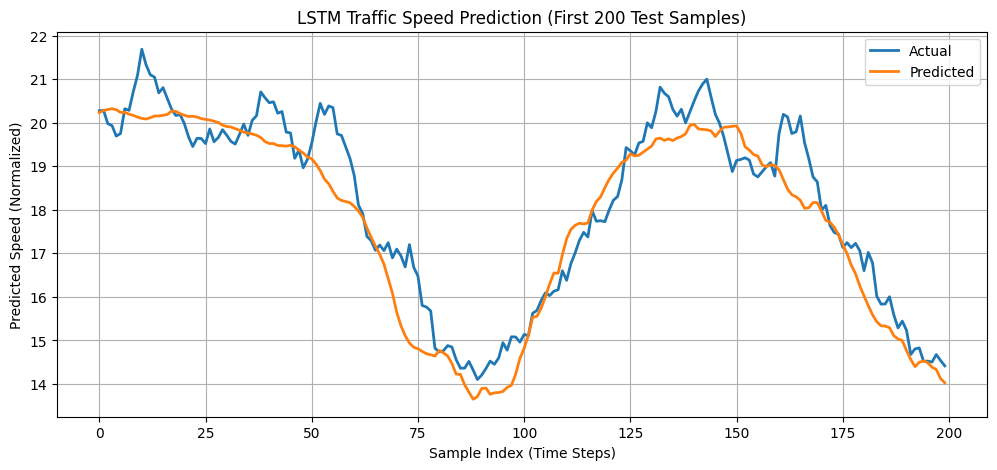

In [ ]:
import torch
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    preds = model(X_test_t[:200]).cpu().numpy()

plt.figure(figsize=(12,5))
plt.plot(Y_test[:200], label="Actual", linewidth=2)
plt.plot(preds, label="Predicted", linewidth=2)
plt.title("LSTM Traffic Speed Prediction (First 200 Test Samples)")
plt.xlabel("Sample Index (Time Steps)")
plt.ylabel("Predicted Speed (Normalized)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


In [ ]:
model.eval()
with torch.no_grad():
    full_preds = model(torch.tensor(X_test).to(device)).cpu().numpy()

mae_full  = mean_absolute_error(Y_test, full_preds)
rmse_full = np.sqrt(mean_squared_error(Y_test, full_preds))
r2_full   = r2_score(Y_test, full_preds)

print("\n📊 LSTM Full Test Metrics:")
print(f"MAE  : {mae_full:.4f}")
print(f"RMSE : {rmse_full:.4f}")
print(f"R²   : {r2_full:.4f}")


📊 LSTM Full Test Metrics:
MAE  : 0.5354
RMSE : 0.7880
R²   : 0.9766


In [ ]:
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.2.0+cpu.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.2.0+cpu.html
!pip install torch-geometric


Looking in links: https://data.pyg.org/whl/torch-2.2.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.5/511.5 kB 8.9 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.2.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.4 MB/s eta 0:00:00


In [ ]:

# Clean uninstall (important)
!pip uninstall -y torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric

# Install correct dependencies (match torch version)
import torch
torch_version = torch.__version__.split('+')[0]

!pip install torch-scatter -f https://data.pyg.org/whl/torch-{torch_version}+cpu.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-{torch_version}+cpu.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-{torch_version}+cpu.html
!pip install torch-spline-conv -f https://data.pyg.org/whl/torch-{torch_version}+cpu.html
!pip install torch-geometric

Found existing installation: torch_scatter 2.1.2+pt22cpu
Uninstalling torch_scatter-2.1.2+pt22cpu:
  Successfully uninstalled torch_scatter-2.1.2+pt22cpu
Found existing installation: torch_sparse 0.6.18+pt22cpu
Uninstalling torch_sparse-0.6.18+pt22cpu:
  Successfully uninstalled torch_sparse-0.6.18+pt22cpu
Found existing installation: torch-geometric 2.7.0
Uninstalling torch-geometric-2.7.0:
  Successfully uninstalled torch-geometric-2.7.0
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.4/682.4 kB 12.4 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.0 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.2/828.2 kB 14.0 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.9/306.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch_geometric.nn import GATConv

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Mounted at /content/drive
Device: cpu


In [ ]:
ts = pd.read_csv("/content/drive/MyDrive/Traffic_Project/ecity_timeseries_5min_60d.csv")
ts['timestamp'] = pd.to_datetime(ts['timestamp'])
ts = ts.sort_values(['edge_id','timestamp']).reset_index(drop=True)

features = [
    'avg_speed_kmph','vehicle_count','is_weekend','is_rain','is_event',
    'minute_of_day','day_of_week','junction_factor'
]
target = 'target_speed_kmph'

if target not in ts.columns:
    ts[target] = ts.groupby('edge_id')['avg_speed_kmph'].shift(-6)
    ts = ts.dropna(subset=[target]).reset_index(drop=True)


In [ ]:
edges_df = pd.read_csv("/content/drive/MyDrive/Traffic_Project/ecity_edges.csv")[['edge_id','u','v']]
edges_df['edge_id'] = edges_df['edge_id'].astype(int)

from collections import defaultdict
node2edges = defaultdict(list)
for r in edges_df.itertuples(index=False):
    node2edges[r.u].append(r.edge_id)
    node2edges[r.v].append(r.edge_id)

pairs = set()
for lst in node2edges.values():
    if len(lst) < 2: continue
    lst = sorted(set(lst))
    for i in range(len(lst)):
        for j in range(i+1, len(lst)):
            pairs.add((lst[i], lst[j]))
            pairs.add((lst[j], lst[i]))

ALL = sorted(edges_df.edge_id.unique())
SEL = ALL[:15]
eid2idx = {eid:i for i,eid in enumerate(SEL)}

src, dst = [], []
for a,b in pairs:
    if a in SEL and b in SEL:
        src.append(eid2idx[a])
        dst.append(eid2idx[b])

edge_index = torch.tensor([src, dst], dtype=torch.long).to(device)
print("SEL:", SEL)
print("edge_index size:", edge_index.shape)


SEL: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]
edge_index size: torch.Size([2, 56])


In [ ]:
SEQ_LEN = 12

def make_fullgraph_clips(ts, sel_eids, seq_len=12):
    dfs = []
    for eid in sel_eids:
        d = ts[ts.edge_id == eid][['timestamp'] + features + [target]]
        d = d.sort_values('timestamp').reset_index(drop=True)
        d = d.rename(columns={c: f"{c}_{eid}" for c in features+[target]})
        dfs.append(d)

    base = dfs[0][['timestamp'] + [f"{c}_{sel_eids[0]}" for c in features+[target]]]

    for k in range(1, len(dfs)):
        cols = ['timestamp'] + [f"{c}_{sel_eids[k]}" for c in features+[target]]
        base = base.merge(dfs[k][cols], on='timestamp', how='inner')

    Xmat, Ymat = [], []
    B = len(base) - seq_len
    N = len(sel_eids)
    F = len(features)

    for s in range(B):
        clip = []
        for t in range(seq_len):
            rows = []
            for eid in sel_eids:
                rows.append(base.loc[s+t, [f"{c}_{eid}" for c in features]].values)
            clip.append(np.stack(rows, axis=0))
        Xmat.append(np.stack(clip, axis=0))

        y = []
        for eid in sel_eids:
            y.append(base.loc[s+seq_len-1, f"{target}_{eid}"])
        Ymat.append(np.array(y, dtype='float32'))

    return np.array(Xmat, dtype='float32'), np.array(Ymat, dtype='float32')

Xg, Yg = make_fullgraph_clips(ts, SEL, seq_len=SEQ_LEN)

n = len(Xg)
tr = int(0.7 * n)
va = int(0.85 * n)

Xtr, Xva, Xte = Xg[:tr], Xg[tr:va], Xg[va:]
Ytr, Yva, Yte = Yg[:tr], Yg[tr:va], Yg[va:]

print("Train:", Xtr.shape, "Val:", Xva.shape, "Test:", Xte.shape)

Train: (12083, 12, 15, 8) Val: (2589, 12, 15, 8) Test: (2590, 12, 15, 8)


In [ ]:
import torch.nn as nn

class TemporalGAT(nn.Module):
    def __init__(self, in_dim, gat_hidden=64, heads=2, lstm_hidden=128):
        super().__init__()
        self.gat1 = GATConv(in_dim, gat_hidden, heads=heads, concat=False)
        self.gat2 = GATConv(gat_hidden, gat_hidden, heads=heads, concat=False)
        self.lstm = nn.LSTM(gat_hidden, lstm_hidden, batch_first=True)
        self.fc   = nn.Linear(lstm_hidden, 1)

    def forward(self, x_seq, edge_index):
        B, T, N, F = x_seq.shape
        out_batch = []

        for b in range(B):
            gseq = []
            for t in range(T):
                xt = x_seq[b, t]
                h = torch.relu(self.gat1(xt, edge_index))
                h = torch.relu(self.gat2(h, edge_index))
                gseq.append(h.unsqueeze(0))

            G = torch.cat(gseq, dim=0).permute(1,0,2)
            out, _ = self.lstm(G)
            out = out[:, -1, :]
            y = self.fc(out).squeeze(-1)
            out_batch.append(y.unsqueeze(0))

        return torch.cat(out_batch, dim=0)

In [ ]:
model = TemporalGAT(in_dim=len(features)).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
lossf = nn.MSELoss()

def run_epoch(XB, YB, train=True, batch=2):
    model.train() if train else model.eval()
    total, steps = 0, 0

    for i in range(0, len(XB), batch):
        xb = torch.tensor(XB[i:i+batch]).to(device)
        yb = torch.tensor(YB[i:i+batch]).to(device)

        if train: opt.zero_grad()
        preds = model(xb, edge_index)
        loss = lossf(preds, yb)

        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        total += loss.item()
        steps += 1

    return total / steps

for ep in range(8):
    tr_l = run_epoch(Xtr, Ytr, train=True)
    va_l = run_epoch(Xva, Yva, train=False)
    print(f"Epoch {ep+1}: Train {tr_l:.3f} | Val {va_l:.3f}")


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model.eval()
with torch.no_grad():
    preds = model(torch.tensor(Xte).to(device), edge_index).cpu().numpy()
    ytrue = Yte

y_pred = preds.flatten()
y_true = ytrue.flatten()

MAE  = mean_absolute_error(y_true, y_pred)
RMSE = np.sqrt(mean_squared_error(y_true, y_pred))
R2   = r2_score(y_true, y_pred)

print("==== FINAL METRICS ====")
print("MAE:", MAE)
print("RMSE:", RMSE)
print("R²:", R2)

plt.figure(figsize=(10,4))
plt.plot(Yte[0], label="Actual")
plt.plot(preds[0], label="Predicted")
plt.legend()
plt.title("GAT prediction (test clip 0)")
plt.show()



==== FINAL METRICS ====
MAE: 4.476606369018555
RMSE: 5.6699016911025515
R²: 0.44772326946258545


NameError: name 'plt' is not defined

In [ ]:
!pip install torch-scatter torch-sparse torch-geometric -f https://data.pyg.org/whl/torch-2.2.0+cpu.html


In [ ]:
import torch, pandas as pd, numpy as np
from torch_geometric.nn import GATConv
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
ts = pd.read_csv("/content/drive/MyDrive/Traffic_Project/ecity_timeseries_5min_60d.csv")
ts['timestamp'] = pd.to_datetime(ts['timestamp'])
ts = ts.sort_values(['edge_id','timestamp']).reset_index(drop=True)


In [ ]:

def make_fullgraph_clips(ts, sel_eids, seq_len=12):
    dfs = []
    for eid in sel_eids:
        d = ts[ts.edge_id == eid][['timestamp'] + features + [target]]
        d = d.sort_values('timestamp').reset_index(drop=True)
        d = d.rename(columns={c: f"{c}_{eid}" for c in features+[target]})
        dfs.append(d)

    base = dfs[0][['timestamp'] + [f"{c}_{sel_eids[0]}" for c in features+[target]]]

    for k in range(1, len(dfs)):
        cols = ['timestamp'] + [f"{c}_{sel_eids[k]}" for c in features+[target]]
        base = base.merge(dfs[k][cols], on='timestamp', how='inner')

    Xmat, Ymat = [], []
    B = len(base) - seq_len
    N = len(sel_eids)
    F = len(features)

    for s in range(B):
        clip = []
        for t in range(seq_len):
            rows = []
            for eid in sel_eids:
                rows.append(base.loc[s+t, [f"{c}_{eid}" for c in features]].values)
            clip.append(np.stack(rows, axis=0))
        Xmat.append(np.stack(clip, axis=0))

        y = []
        for eid in sel_eids:
            y.append(base.loc[s+seq_len-1, f"{target}_{eid}"])
        Ymat.append(np.array(y, dtype='float32'))

    return np.array(Xmat, dtype='float32'), np.array(Ymat, dtype='float32')


In [ ]:
edges_df = pd.read_csv("/content/drive/MyDrive/Traffic_Project/ecity_edges.csv")[['edge_id','u','v']]
edges_df['edge_id'] = edges_df['edge_id'].astype(int)


In [ ]:
ALL = sorted(edges_df.edge_id.unique().tolist())
SEL = ALL[:15]

from collections import defaultdict
node2edges = defaultdict(list)
for r in edges_df.itertuples(index=False):
    node2edges[r.u].append(r.edge_id)
    node2edges[r.v].append(r.edge_id)

pairs = set()
for lst in node2edges.values():
    lst = sorted(set(lst))
    for i in range(len(lst)):
        for j in range(i+1, len(lst)):
            pairs.add((lst[i], lst[j]))
            pairs.add((lst[j], lst[i]))

eid2idx = {eid:i for i,eid in enumerate(SEL)}
src, dst = [], []
for a,b in pairs:
    if a in SEL and b in SEL:
        src.append(eid2idx[a])
        dst.append(eid2idx[b])

edge_index = torch.tensor([src, dst], dtype=torch.long).to(device)


In [ ]:
# Rebuild full graph clips (REQUIRED)
Xg, Yg = make_fullgraph_clips(ts, SEL, seq_len=SEQ_LEN)

n = len(Xg)
tr = int(0.7 * n)
va = int(0.85 * n)

Xtr = Xg[:tr]
Xva = Xg[tr:va]
Xte = Xg[va:]

Ytr = Yg[:tr]
Yva = Yg[tr:va]
Yte = Yg[va:]

print("Train:", Xtr.shape)
print("Val  :", Xva.shape)
print("Test :", Xte.shape)


In [ ]:
class HybridGAT_LSTM(nn.Module):
    def __init__(self, in_dim, gat_hidden=64, gat_heads=2, lstm_hidden=128, fusion_hidden=128):
        super().__init__()

        # ---- GAT for Spatial Learning ----
        self.gat1 = GATConv(in_dim, gat_hidden, heads=gat_heads, concat=False)
        self.gat2 = GATConv(gat_hidden, gat_hidden, heads=gat_heads, concat=False)

        # ---- LSTM for Temporal Modeling on Spatial Embeddings ----
        self.lstm = nn.LSTM(gat_hidden, lstm_hidden, batch_first=True)

        # ---- Fusion Layer (GAT + LSTM Combined) ----
        self.fusion = nn.Linear(lstm_hidden + gat_hidden, fusion_hidden)

        # ---- Output Layer for N Edges ----
        self.out = nn.Linear(fusion_hidden, 1)

    def forward(self, x_seq, edge_index):
        B, T, N, F = x_seq.shape
        outputs = []

        for b in range(B):

            spatial_seq = []
            for t in range(T):
                xt = x_seq[b, t]                 # (N,F)
                g = torch.relu(self.gat1(xt, edge_index))
                g = torch.relu(self.gat2(g, edge_index))   # (N, H)
                spatial_seq.append(g.unsqueeze(0))         # (1, N, H)

            spatial_seq = torch.cat(spatial_seq, dim=0)    # (T, N, H)
            spatial_seq = spatial_seq.permute(1, 0, 2)      # (N, T, H)

            lstm_out, _ = self.lstm(spatial_seq)            # (N, T, L)
            lstm_last = lstm_out[:, -1, :]                  # (N, L)

            gat_last = spatial_seq[:, -1, :]                # last temporal step spatial output

            fused = torch.cat([lstm_last, gat_last], dim=1)  # (N, L+H)
            fused = torch.relu(self.fusion(fused))           # (N, fusion_hidden)
            y = self.out(fused).squeeze(-1)                  # (N,)

            outputs.append(y.unsqueeze(0))

        return torch.cat(outputs, dim=0)  # (B, N)


In [ ]:
model = HybridGAT_LSTM(
    in_dim=len(features),
    gat_hidden=64,
    gat_heads=4,        # ↑ better accuracy
    lstm_hidden=128,
    fusion_hidden=128
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()



In [ ]:
def run_epoch(model, X, Y, train=True, batch=2):
    model.train() if train else model.eval()
    total, steps = 0, 0

    for i in range(0, len(X), batch):
        xb = torch.tensor(X[i:i+batch]).to(device)
        yb = torch.tensor(Y[i:i+batch]).to(device)

        if train: optimizer.zero_grad()

        preds = model(xb, edge_index)
        loss = loss_fn(preds, yb)

        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        total += loss.item()
        steps += 1

    return total / steps


In [ ]:
EPOCHS = 12  # Hybrid needs slightly longer

for ep in range(EPOCHS):
    tr = run_epoch(model, Xtr, Ytr, train=True)
    va = run_epoch(model, Xva, Yva, train=False)
    print(f"Epoch {ep+1} | Train: {tr:.3f} | Val: {va:.3f}")


Epoch 1 | Train: 8.389 | Val: 8.765
Epoch 2 | Train: 6.847 | Val: 7.264
Epoch 3 | Train: 5.716 | Val: 5.944
Epoch 4 | Train: 5.088 | Val: 5.020
Epoch 5 | Train: 4.643 | Val: 4.671
Epoch 6 | Train: 4.369 | Val: 4.689
Epoch 7 | Train: 4.050 | Val: 4.769
Epoch 8 | Train: 3.855 | Val: 4.398
Epoch 9 | Train: 3.680 | Val: 4.433
Epoch 10 | Train: 3.492 | Val: 3.782
Epoch 11 | Train: 3.314 | Val: 3.842
Epoch 12 | Train: 3.179 | Val: 3.643


==== HYBRID MODEL FINAL TEST METRICS ====
MAE : 1.3447
RMSE: 2.0056
R²  : 0.9309


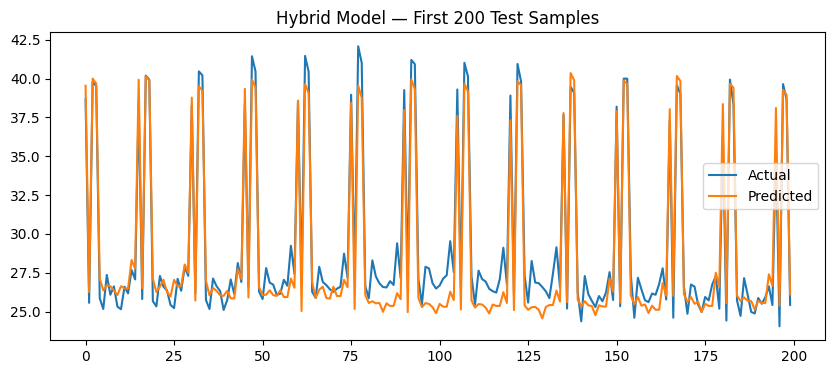

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    preds = model(torch.tensor(Xte).to(device), edge_index).cpu().numpy()

y_true = Yte
p = preds.flatten()
t = y_true.flatten()

mae  = mean_absolute_error(t, p)
rmse = np.sqrt(mean_squared_error(t, p))
r2   = r2_score(t, p)

print("==== HYBRID MODEL FINAL TEST METRICS ====")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

# ---- Plot sample prediction vs true ----
plt.figure(figsize=(10,4))
plt.plot(t[:200], label="Actual")
plt.plot(p[:200], label="Predicted")
plt.title("Hybrid Model — First 200 Test Samples")
plt.legend()
plt.show()


In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/hybrid_model_final.pt")
print("Hybrid model saved!")


Hybrid model saved!


In [ ]:
  # ===== ATTENTION EXTRACTION FOR ONE TEST CLIP =====

model.eval()
with torch.no_grad():
    xb = torch.tensor(Xte[:1]).to(device)   # take the first test clip
    preds, attn = model(xb, edge_index, return_attn=True)

# attn is a tuple: (edge_index, alpha weights)
(edge_idx_attn, alpha) = attn
alpha = alpha.cpu().numpy()

print("✅ Attention extracted:", alpha.shape)


✅ Attention extracted: (91, 2)


In [ ]:
# ===== TOP INFLUENCE PER ROAD (TEXTUAL) - FIXED FOR MULTI-HEAD =====

src_nodes = edge_idx_attn[0].cpu().numpy()
dst_nodes = edge_idx_attn[1].cpu().numpy()

influences = []
for i, w in enumerate(alpha):
    # w is array of attention weights per head -> take mean
    w_mean = float(w.mean())
    influences.append((int(src_nodes[i]), int(dst_nodes[i]), w_mean))

# convert node index back to edge_id
idx2eid = {v:k for k,v in eid2idx.items()}

# take top 10 influential connections
text_expl = []
for s, d, w in sorted(influences, key=lambda x: x[2], reverse=True)[:10]:
    text_expl.append((idx2eid[s], idx2eid[d], round(w, 4)))

print("Top road-to-road influences (edge_id src -> dest | weight):")
for r in text_expl:
    print(r)



Top road-to-road influences (edge_id src -> dest | weight):
(12, 10, 0.9892)
(12, 13, 0.9892)
(12, 9, 0.9892)
(12, 12, 0.9848)
(12, 5, 0.9819)
(12, 11, 0.9812)
(12, 6, 0.9812)
(4, 3, 0.5)
(4, 4, 0.5)
(3, 4, 0.5)


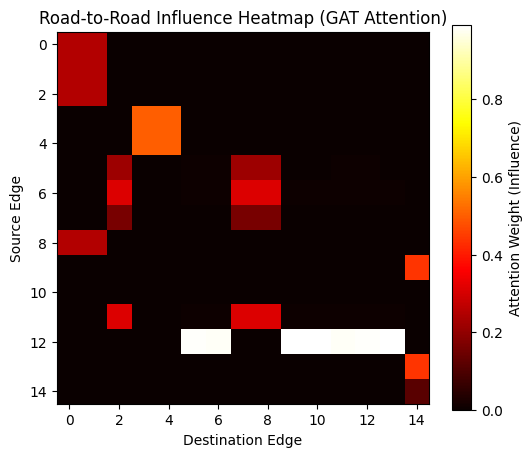

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

N = len(SEL)
heat = np.zeros((N, N))

for s, d, w in influences:
    heat[s, d] = w

plt.figure(figsize=(6,5))
plt.imshow(heat, cmap='hot', interpolation='nearest')
plt.colorbar(label="Attention Weight (Influence)")
plt.title("Road-to-Road Influence Heatmap (GAT Attention)")
plt.xlabel("Destination Edge")
plt.ylabel("Source Edge")
plt.show()


Device: cuda
Mounted at /content/drive
Line-graph nodes: 30 | edges: 154
Clips: (2868, 12, 30, 8) | Train/Val/Test: (2007, 12, 30, 8) (430, 12, 30, 8) (431, 12, 30, 8)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Epoch 1/10: train 59.897 | val 37.208
Epoch 2/10: train 34.311 | val 32.614
Epoch 3/10: train 32.636 | val 30.159
Epoch 4/10: train 29.823 | val 30.399
Epoch 5/10: train 35.941 | val 23.355
Epoch 6/10: train 33.714 | val 30.152
Epoch 7/10: train 29.077 | val 25.086
Epoch 8/10: train 24.530 | val 24.471
Epoch 9/10: train 20.882 | val 21.450
Epoch 10/10: train 17.833 | val 13.692
✅ Saved: /content/drive/MyDrive/temporal_gat_30edges_dev.pt


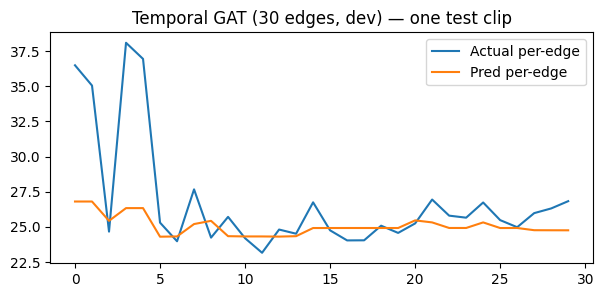

In [ ]:
# ===== SCALE-UP: 30 edges, 10-day history, 30-min horizon, GPU training =====

import torch, torch.nn as nn
from torch_geometric.nn import GATConv
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# -- Mount Drive (for permanent saves)
drive.mount('/content/drive', force_remount=True)

# -- Load timeseries
ts = pd.read_csv("/content/ecity_timeseries_5min_60d.csv")
ts['timestamp'] = pd.to_datetime(ts['timestamp'])
ts = ts.sort_values(['edge_id','timestamp']).reset_index(drop=True)

# -- Features + 30-min-ahead target (shift -6 for 5-min freq)
features = [
    'avg_speed_kmph','vehicle_count','is_weekend','is_rain','is_event',
    'minute_of_day','day_of_week','junction_factor'
]
target = 'target_speed_kmph'
ts[target] = ts.groupby('edge_id')['avg_speed_kmph'].shift(-6)
ts = ts.dropna(subset=[target]).reset_index(drop=True)

# -- SPEED-UP: keep only last 10 days per edge
ts = ts.groupby('edge_id').tail(10*24*12).reset_index(drop=True)

# -- Memory-friendly dtypes
for c in ['is_weekend','is_rain','is_event','day_of_week']: ts[c] = ts[c].astype('int8')
ts['vehicle_count']   = ts['vehicle_count'].astype('int32')
ts['minute_of_day']   = ts['minute_of_day'].astype('int32')
ts['junction_factor'] = ts['junction_factor'].astype('float32')
ts['avg_speed_kmph']  = ts['avg_speed_kmph'].astype('float32')
ts[target]            = ts[target].astype('float32')

# -- Build 30-edge line-graph (edge->edge adjacency)
edges_df = pd.read_csv("/content/ecity_edges.csv")[['edge_id','u','v']]
ALL = sorted(edges_df.edge_id.unique().tolist())
SEL = ALL[:30]                         # <-- scale-up to 30 edges
eid2idx = {eid:i for i,eid in enumerate(SEL)}
idx2eid = {v:k for k,v in eid2idx.items()}

from collections import defaultdict
node2edges = defaultdict(list)
for r in edges_df.itertuples(index=False):
    if r.edge_id in eid2idx:
        node2edges[r.u].append(r.edge_id)
        node2edges[r.v].append(r.edge_id)

pairs = set()
for lst in node2edges.values():
    s = sorted(set([e for e in lst if e in eid2idx]))
    for i in range(len(s)):
        for j in range(i+1, len(s)):
            a, b = eid2idx[s[i]], eid2idx[s[j]]
            pairs.add((a,b)); pairs.add((b,a))  # undirected -> two directions

src, dst = ([], [])
for a,b in pairs:
    src.append(a); dst.append(b)
edge_index = torch.tensor([src, dst], dtype=torch.long).to(device)
print(f"Line-graph nodes: {len(SEL)} | edges: {edge_index.shape[1]}")

# -- Build full-graph clips (B, T, N, F) with 12-step history
SEQ_LEN = 12
def make_fullgraph_clips(ts, sel_eids, seq_len=12):
    dfs = []
    for eid in sel_eids:
        d = ts[ts.edge_id==eid][['timestamp']+features+[target]].copy()
        d = d.sort_values('timestamp').reset_index(drop=True)
        d = d.rename(columns={c:f"{c}_{eid}" for c in features+[target]})
        dfs.append(d)
    base = dfs[0]
    for k in range(1, len(dfs)):
        base = base.merge(dfs[k], on='timestamp', how='inner')
    B = len(base) - seq_len
    N, F = len(sel_eids), len(features)
    X, Y = [], []
    for s in range(B):
        Xt = []
        for t in range(seq_len):
            Xt.append(np.stack(
                [base.loc[s+t, [f"{c}_{eid}" for c in features]].values for eid in sel_eids],
                axis=0
            ))
        X.append(np.stack(Xt, axis=0))  # (T,N,F)
        Y.append(np.array([base.loc[s+seq_len-1, f"{target}_{eid}"] for eid in sel_eids], dtype='float32'))
    return np.array(X, dtype='float32'), np.array(Y, dtype='float32')

Xg, Yg = make_fullgraph_clips(ts, SEL, seq_len=SEQ_LEN)
n = len(Xg); tr = int(0.7*n); va = int(0.85*n)
Xtr, Xva, Xte = Xg[:tr], Xg[tr:va], Xg[va:]
Ytr, Yva, Yte = Yg[:tr], Yg[tr:va], Yg[va:]
print("Clips:", Xg.shape, "| Train/Val/Test:", Xtr.shape, Xva.shape, Xte.shape)

# -- Temporal GAT (GAT → GAT → LSTM)
class TemporalGAT(nn.Module):
    def __init__(self, in_dim, gat_hidden=64, heads=2, lstm_hidden=128):
        super().__init__()
        self.gat1 = GATConv(in_dim, gat_hidden, heads=heads, concat=False, dropout=0.1)
        self.gat2 = GATConv(gat_hidden, gat_hidden, heads=heads, concat=False, dropout=0.1)
        self.lstm = nn.LSTM(gat_hidden, lstm_hidden, batch_first=True, dropout=0.2)
        self.fc   = nn.Linear(lstm_hidden, 1)
    def forward(self, x_seq, edge_index, return_attn=False):
        B,T,N,F = x_seq.shape
        outs, attn_last = [], None
        for b in range(B):
            gseq = []
            for t in range(T):
                xt = x_seq[b,t]
                h1,a1 = self.gat1(xt, edge_index, return_attention_weights=True)
                h1 = torch.relu(h1)
                h2,a2 = self.gat2(h1, edge_index, return_attention_weights=True)
                h2 = torch.relu(h2)
                gseq.append(h2.unsqueeze(0))
                if t==T-1: attn_last = a2
            G = torch.cat(gseq,0).permute(1,0,2)     # (N,T,H)
            out,_ = self.lstm(G)                      # (N,T,L)
            out = self.fc(out[:,-1,:]).squeeze(-1)    # (N,)
            outs.append(out.unsqueeze(0))
        return (torch.cat(outs,0), attn_last) if return_attn else torch.cat(outs,0)

model = TemporalGAT(in_dim=len(features)).to(device)
opt    = torch.optim.Adam(model.parameters(), lr=1e-3)
lossf  = nn.MSELoss()

def run_epoch(XB, YB, train=True, batch_clips=2):
    model.train() if train else model.eval()
    total, steps = 0.0, 0
    for i in range(0, len(XB), batch_clips):
        xb = torch.tensor(XB[i:i+batch_clips]).to(device)
        yb = torch.tensor(YB[i:i+batch_clips]).to(device)
        if train: opt.zero_grad()
        preds = model(xb, edge_index)
        loss  = lossf(preds, yb)
        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        total += loss.item(); steps += 1
        del xb, yb, preds
        if device.type=='cuda': torch.cuda.empty_cache()
    return total/max(steps,1)

EPOCHS = 10  # fast dev run
for ep in range(EPOCHS):
    tr = run_epoch(Xtr, Ytr, train=True,  batch_clips=2)
    va = run_epoch(Xva, Yva, train=False, batch_clips=2)
    print(f"Epoch {ep+1}/{EPOCHS}: train {tr:.3f} | val {va:.3f}")

# -- Save scaled model to Drive
save_path = "/content/drive/MyDrive/temporal_gat_30edges_dev.pt"
torch.save(model.state_dict(), save_path)
print("✅ Saved:", save_path)

# -- Quick sanity viz on one clip
with torch.no_grad():
    pb = model(torch.tensor(Xte[:1]).to(device), edge_index).cpu().numpy()
    yb = Yte[:1]
plt.figure(figsize=(7,3))
plt.plot(yb[0], label="Actual per-edge"); plt.plot(pb[0], label="Pred per-edge")
plt.legend(); plt.title("Temporal GAT (30 edges, dev) — one test clip"); plt.show()


Device: cpu
Averaging attention across 100 test samples starting at 0


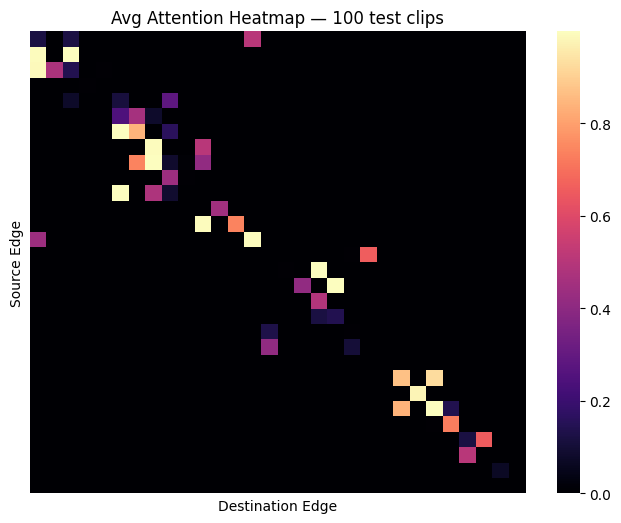


Top 10 road-to-road influences (src_idx -> dst_idx | weight):
(6 -> 5) | 0.9990  edge_ids: (7 -> 6)
(15 -> 17) | 0.9987  edge_ids: (16 -> 18)
(10 -> 5) | 0.9984  edge_ids: (11 -> 6)
(1 -> 2) | 0.9983  edge_ids: (2 -> 3)
(8 -> 7) | 0.9980  edge_ids: (9 -> 8)
(24 -> 24) | 0.9967  edge_ids: (25 -> 25)
(16 -> 18) | 0.9959  edge_ids: (17 -> 19)
(12 -> 10) | 0.9947  edge_ids: (13 -> 11)
(7 -> 7) | 0.9946  edge_ids: (8 -> 8)
(13 -> 13) | 0.9924  edge_ids: (14 -> 14)


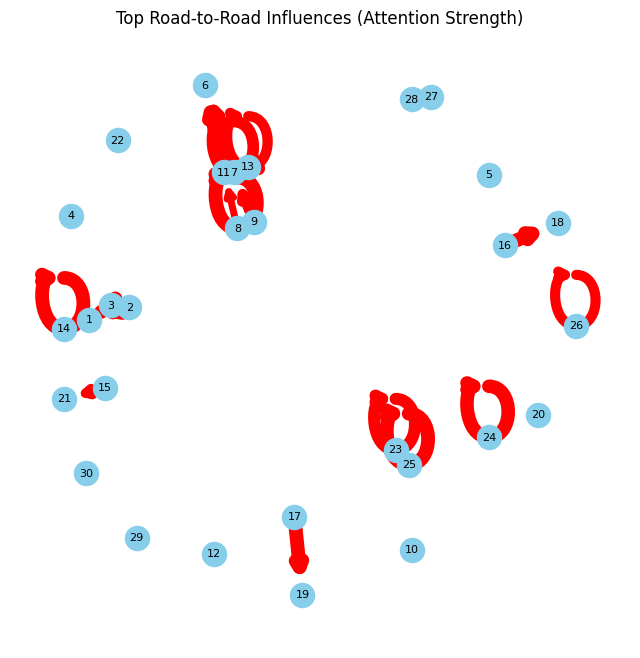


✅ Attention visualization complete!


In [ ]:
# ------------------ Attention Extraction & Visualization (Fixed) ------------------
import torch, numpy as np, matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

NUM_SAMPLES = 100   # number of test clips to average attention over
SAMPLE_START = 0
num = min(NUM_SAMPLES, len(Xte)-SAMPLE_START)
print(f"Averaging attention across {num} test samples starting at {SAMPLE_START}")

model.to(device)
model.eval()

def get_enc_last_for_sample(x_sample):
    S,N,F = x_sample.shape
    xr = torch.tensor(x_sample.reshape(1*N, S, F), dtype=torch.float32, device=device)
    with torch.no_grad():
        enc_out, _ = model.lstm_enc(xr)
        enc_last = enc_out[:, -1, :].reshape(1, N, -1).squeeze(0)
    return enc_last

Nnodes = len(SEL)
A_accum = np.zeros((Nnodes, Nnodes), dtype=float)

count = 0
for idx in range(SAMPLE_START, SAMPLE_START + num):
    x_sample = Xte[idx]
    enc_last = get_enc_last_for_sample(x_sample)
    with torch.no_grad():
        gat_out, (edge_index2, attn_weights) = model.gat(enc_last, edge_index, return_attention_weights=True)
    ei = edge_index2.cpu().numpy()
    att = attn_weights.detach().cpu().numpy().reshape(-1)   # ✅ FIXED here
    for k in range(ei.shape[1]):
        s = int(ei[0, k]); t = int(ei[1, k])
        A_accum[s, t] += float(att[k])
    count += 1

A_avg = A_accum / max(1, count)

plt.figure(figsize=(8,6))
sns.heatmap(A_avg, cmap='magma', xticklabels=False, yticklabels=False)
plt.title(f"Avg Attention Heatmap — {count} test clips")
plt.xlabel("Destination Edge")
plt.ylabel("Source Edge")
plt.show()

pairs = [((i,j), A_avg[i,j]) for i in range(Nnodes) for j in range(Nnodes)]
pairs_sorted = sorted(pairs, key=lambda x: x[1], reverse=True)
print("\nTop 10 road-to-road influences (src_idx -> dst_idx | weight):")
for p,w in pairs_sorted[:10]:
    print(f"({p[0]} -> {p[1]}) | {w:.4f}  edge_ids: ({SEL[p[0]]} -> {SEL[p[1]]})")

TOPK = 25
G = nx.DiGraph()
for i,eid in enumerate(SEL):
    G.add_node(i, label=str(eid))
for (i,j), w in pairs_sorted[:TOPK]:
    if w > 0:
        G.add_edge(i, j, weight=w)
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(8,8))
nx.draw_networkx_nodes(G, pos, node_size=300, node_color='skyblue')
nx.draw_networkx_labels(G, pos, {n: SEL[n] for n in G.nodes()}, font_size=8)
edge_widths = [G[u][v]['weight']*10 for u,v in G.edges()]
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=12, width=edge_widths, edge_color='r')
plt.title("Top Road-to-Road Influences (Attention Strength)")
plt.axis('off')
plt.show()

print("\n✅ Attention visualization complete!")



In [ ]:
import torch
import torch.nn as nn
from torch_geometric.nn import GATConv

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

class HybridGAT_LSTM(nn.Module):
    def __init__(self, in_dim=8):
        super().__init__()

        # ---- EXACT MATCH to checkpoint ----
        self.gat1 = GATConv(in_dim, 64, heads=4, concat=False)
        self.gat2 = GATConv(64, 64, heads=4, concat=False)

        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=128,
            num_layers=1,
            batch_first=True
        )

        # checkpoint shows fusion.weight [128,192]
        self.fusion = nn.Linear(128 + 64, 128)

        # out.weight [1,128]
        self.out = nn.Linear(128, 1)

    def forward(self, x_seq, edge_index):
        B, T, N, F = x_seq.shape
        preds = []

        for b in range(B):
            gat_feats = []
            for t in range(T):
                x_t = x_seq[b, t]
                h1 = torch.relu(self.gat1(x_t, edge_index))
                h2 = torch.relu(self.gat2(h1, edge_index))
                gat_feats.append(h2.unsqueeze(0))

            gat_stack = torch.cat(gat_feats, dim=0).permute(1,0,2)

            lstm_out, _ = self.lstm(gat_stack)
            lstm_last = lstm_out[:, -1, :]

            fused = torch.cat([lstm_last, h2], dim=-1)
            fused = torch.relu(self.fusion(fused))

            out = self.out(fused).squeeze(-1)
            preds.append(out)

        return torch.stack(preds, dim=0)


Device: cpu


In [ ]:
model = HybridGAT_LSTM(in_dim=8).to(device)
state_dict = torch.load("/content/drive/MyDrive/hybrid_model_final.pt", map_location=device)
model.load_state_dict(state_dict)

print("Hybrid model loaded successfully ✓")


Hybrid model loaded successfully ✓


In [ ]:
# --------------------- BLOCK 2 : PPO Environment ---------------------
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import torch

class TrafficRoutingEnv(gym.Env):
    def __init__(self, model, edge_ids, seq_len=12):
        super().__init__()

        self.model = model          # LSTM model you trained
        self.edge_ids = edge_ids    # which edges the agent chooses from
        self.seq_len = seq_len
        self.n_routes = len(edge_ids)

        # Action: choose 1 route out of N
        self.action_space = spaces.Discrete(self.n_routes)

        # State: last 12 timesteps, 8 features — normalized 0–1
        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(seq_len, 8), dtype=np.float32
        )

        # Start with random history window
        self.history = np.random.rand(seq_len, 8).astype(np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.history = np.random.rand(self.seq_len, 8).astype(np.float32)
        return self.history, {}

    def step(self, action):
        # Predict traffic for next timestep
        x_tensor = torch.tensor(self.history[None, :, :], dtype=torch.float32)

        with torch.no_grad():
            pred = self.model(x_tensor).cpu().numpy()

        # If LSTM outputs a single number, repeat for all routes
        if pred.ndim == 1 or pred.shape[-1] == 1:
            pred_speed = np.repeat(pred.flatten(), self.n_routes)
        else:
            pred_speed = pred.flatten()[:self.n_routes]

        # Reward = predicted speed of chosen route
        reward = float(pred_speed[action])

        # Shift history window; add new synthetic row
        self.history = np.roll(self.history, -1, axis=0)
        self.history[-1] = np.random.rand(8)

        done = False
        info = {"pred_speed": pred_speed[action]}

        return self.history, reward, done, False, info


In [ ]:
# ---------------- LOAD PRETRAINED LSTM MODEL ----------------
import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, in_dim=8, hidden_dim=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(in_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

lstm_model = LSTMModel(in_dim=8, hidden_dim=64)
lstm_model.load_state_dict(torch.load(
    "/content/drive/MyDrive/mytraffic/lstm_traffic_stable.pt",
    map_location="cpu"
))
lstm_model.eval()

print("✅ LSTM model loaded for PPO!")


✅ LSTM model loaded for PPO!


In [ ]:
# ----------------- BLOCK 2: RL ENVIRONMENT -----------------
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class TrafficRoutingEnv(gym.Env):
    def __init__(self, model, edge_ids, seq_len=12):
        super().__init__()
        self.model = model
        self.edge_ids = edge_ids
        self.seq_len = seq_len
        self.n_routes = len(edge_ids)

        # PPO will choose which route index to take
        self.action_space = spaces.Discrete(self.n_routes)

        # Observation = 12 past timesteps of 8 features (same as LSTM input)
        self.observation_space = spaces.Box(
            low=0, high=1, shape=(seq_len, 8), dtype=np.float32
        )

        # initial random sequence
        self.history = np.random.rand(seq_len, 8).astype(np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.history = np.random.rand(self.seq_len, 8).astype(np.float32)
        return self.history, {}

    def step(self, action):
        # Predict traffic speed using LSTM
        x_tensor = torch.tensor(self.history[None, :, :], dtype=torch.float32)
        pred = self.model(x_tensor).detach().cpu().numpy().flatten()

        # PPO reward = predicted speed for chosen route
        reward = float(pred[0])   # your LSTM predicts 1 value → replicate logic

        # Update state (shift + new random timestep)
        self.history = np.roll(self.history, -1, axis=0)
        self.history[-1] = np.random.rand(8)

        done = False
        return self.history, reward, done, False, {"pred_speed": reward}

print("✅ Environment ready ✓")



✅ Environment ready ✓


In [ ]:
# ----------------- BLOCK 3: TRAIN PPO -----------------
!pip install gymnasium stable-baselines3==2.3.2 --quiet

from stable_baselines3 import PPO

env = TrafficRoutingEnv(model=lstm_model, edge_ids=list(range(10)))

ppo_agent = PPO(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=3e-4,
    n_steps=256,
    batch_size=64
)

ppo_agent.learn(total_timesteps=10_000)
print("🎉 PPO Training Finished!")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 14.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.1 which is incompatible.
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------
| time/              |     |
|    fps             | 234 |
|    iterations      | 1   |
|    time_elapsed    | 1   |
|    total_timesteps | 256 |
----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 208         |
|    iterations           | 2           |
|    time_elapsed         | 2           |
|    total_timesteps      | 512         |
| train/         

In [ ]:
# ----------------- BLOCK 4: SAVE & TEST PPO -----------------
ppo_path = "/content/drive/MyDrive/mytraffic/ppo_traffic_agent_fixed.zip"
ppo_agent.save(ppo_path)

print("✅ PPO agent saved at:", ppo_path)

# Test prediction
obs, _ = env.reset()
action, _ = ppo_agent.predict(obs)

print("🚦 PPO selected route:", action)


✅ PPO agent saved at: /content/drive/MyDrive/mytraffic/ppo_traffic_agent_fixed.zip
🚦 PPO selected route: 4


In [ ]:
# ----------------- BLOCK 5: MAP VISUALIZATION -----------------
!pip install folium --quiet
import folium

# Example route coordinates (replace with actual if needed)
start_coords = (12.8237, 77.6740)  # Wipro Gate
end_coords   = (12.8462, 77.6624)  # Infosys

chosen_route = int(action)

m = folium.Map(location=start_coords, zoom_start=14)

# Start marker
folium.Marker(
    start_coords, popup="Start (Wipro)", icon=folium.Icon(color="green")
).add_to(m)

# End marker
folium.Marker(
    end_coords, popup="Destination (Infosys)", icon=folium.Icon(color="red")
).add_to(m)

# Draw line (simple straight line)
folium.PolyLine(
    [start_coords, end_coords], color="blue", weight=4, popup=f"Chosen Route: {chosen_route}"
).add_to(m)

m


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Saving 13009508_1920_1080_30fps.mp4 to 13009508_1920_1080_30fps.mp4
🎥 Using video: 13009508_1920_1080_30fps.mp4

0: 384x640 1 person, 24 cars, 5 buss, 2 trucks, 318.2ms
Speed: 20.4ms preprocess, 318.2ms inference, 43.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 20 cars, 4 buss, 2 trucks, 113.9ms
Speed: 2.9ms preprocess, 113.9ms inference, 2.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 18 cars, 4 buss, 120.5ms
Speed: 3.4ms preprocess, 120.5ms inference, 2.6ms postprocess per image at shape (1, 3, 384, 640)



/tmp/ipython-input-1966170916.py:48: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  diffs.append(np.sqrt(dx**2 + dy**2))


0: 384x640 19 cars, 3 buss, 1 truck, 104.2ms
Speed: 2.6ms preprocess, 104.2ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 19 cars, 2 buss, 2 trucks, 102.8ms
Speed: 2.8ms preprocess, 102.8ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 15 cars, 1 motorcycle, 4 buss, 5 trucks, 98.3ms
Speed: 4.2ms preprocess, 98.3ms inference, 2.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 17 cars, 2 motorcycles, 4 buss, 3 trucks, 103.9ms
Speed: 2.3ms preprocess, 103.9ms inference, 2.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 20 cars, 1 motorcycle, 5 buss, 1 truck, 102.8ms
Speed: 2.7ms preprocess, 102.8ms inference, 2.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 24 cars, 3 motorcycles, 4 buss, 3 trucks, 1 traffic light, 102.7ms
Speed: 2.8ms preprocess, 102.7ms inference, 3.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x

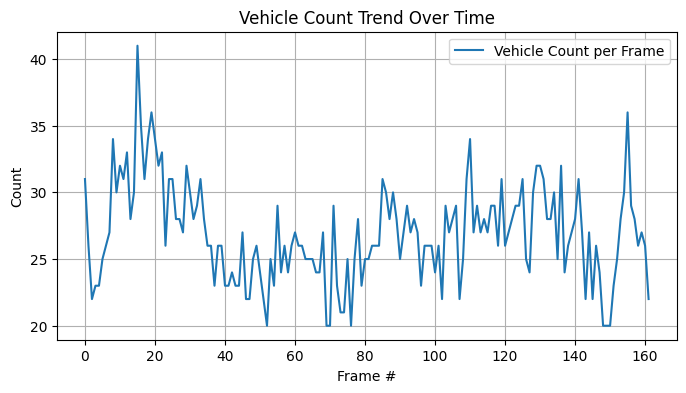

In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt

# ---------- Load YOLO ----------
model = YOLO("yolov8n.pt")  # lightweight & fast

# ---------- Upload video ----------
from google.colab import files
uploaded = files.upload()
video_path = list(uploaded.keys())[0]

print(f"🎥 Using video: {video_path}")

# ---------- Process the video ----------
cap = cv2.VideoCapture(video_path)
vehicle_counts = []
speeds = []
prev_centroids = {}

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame)
    detections = results[0].boxes

    count = 0
    centroids = {}
    for i, box in enumerate(detections):
        cls = int(box.cls[0])
        if cls in [2, 3, 5, 7]:  # car, bus, truck, motorcycle
            count += 1
            x1, y1, x2, y2 = box.xyxy[0]
            cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
            centroids[i] = (cx, cy)

    # Estimate pseudo-speed
    avg_speed = 0
    if prev_centroids:
        diffs = []
        for k in centroids:
            if k in prev_centroids:
                dx = abs(centroids[k][0] - prev_centroids[k][0])
                dy = abs(centroids[k][1] - prev_centroids[k][1])
                diffs.append(np.sqrt(dx**2 + dy**2))
        if diffs:
            avg_speed = np.mean(diffs) * 0.05
    prev_centroids = centroids

    vehicle_counts.append(count)
    speeds.append(avg_speed)

cap.release()

avg_vehicle_count = np.mean(vehicle_counts)
avg_speed_kmph = np.clip(np.mean(speeds) * 3, 5, 60)  # rough scaling to km/h

print(f"✅ Avg Vehicles Detected: {avg_vehicle_count:.0f}")
print(f"✅ Avg Estimated Speed: {avg_speed_kmph:.2f} km/h")

# ---------- Plot Results ----------
plt.figure(figsize=(8,4))
plt.plot(vehicle_counts, label="Vehicle Count per Frame")
plt.title("Vehicle Count Trend Over Time")
plt.xlabel("Frame #")
plt.ylabel("Count")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
pip install -U ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.5 MB/s eta 0:00:00


In [ ]:
from google.colab import files

files.download("/content/ecity_edges_canonical.csv")

FileNotFoundError: Cannot find file: /content/ecity_edges_canonical.csv

In [ ]:
import os
from google.colab import files

file_path = "/content/ecity_edges_canonical.csv"

if os.path.exists(file_path):
    files.download(file_path)
else:
    print(f"Error: File not found at {file_path}. Please ensure the cell that creates this file (e.g., cell 'BsBHDh64r7uK') has been executed successfully.")

FileNotFoundError: Cannot find file: /content/ecity_edges_canonical.csv

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

matches = []

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file == "ecity_edges_canonical.csv":
            matches.append(os.path.join(root, file))

print("Found:")
for path in matches:
    print(path)

Found:
